```python

from timex.ecg import ECGxtract

ecg_extractor = ECGxtract(data_location='/path/to/data', leads=['I', 'II',..], id_names=['ID'], iterative=True, sampling_rate=1000)

ecg_segments = ecg_extractor.extract_segments()
ecg_rates = ecg_extractor.extract_rates()
ecg_timings = ecg_extractor.extract_timings(ecg_segments)
ecg_cwt = ecg_extractor.extract_cwt(ecg_segments)
ecg_dwt = ecg_extractor.extract_dwt(ecg_segments)
ecg_ft = ecg_extractor.extract_ft(ecg_segments)
```

In [ ]:
# add autoreload
%load_ext autoreload
%autoreload 2
import neurokit2 as nk
import numpy as np
from scipy.stats.mstats import gmean
import pandas as pd
import wfdb
import os
import sys
import re
import dotenv
from collections import defaultdict
from tqdm import tqdm

from typing import List, Tuple

from timex.ecg import extractor, dataset
import matplotlib.pyplot as plt

import warnings
from neurokit2.misc import NeuroKitWarning
warnings.filterwarnings("ignore", category=NeuroKitWarning)

In [ ]:
dotenv.load_dotenv('../.env')

In [ ]:
BASE_DIR = os.getenv('ECG_DIR')
DS_DIR = 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'
HEA_DIR = os.path.join(BASE_DIR,
                       DS_DIR,
                       'records500',
                       '00000')

SAMPLE_RATE = 500


In [ ]:
BASE_DIR

In [ ]:
HEA_DIR

In [ ]:
hea_list = [os.path.join(HEA_DIR, f.split('.')[0]) 
            for f in os.listdir(HEA_DIR) if f.endswith('.hea')]

In [ ]:
ecg_path = r'T:\laupodteam\AIOS\Bram\data\ECG\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\records500\00000\00002_hr' # hea_list[5]
hea = os.path.basename(ecg_path)

band_names = wfdb.rdheader(ecg_path).__dict__['sig_name']
record = wfdb.rdrecord(ecg_path)
meta_str = ",".join(wfdb.rdheader(ecg_path).__dict__['comments'])

In [ ]:
record.to_dataframe()

In [ ]:
record.__dict__['comments'], meta_str

In [ ]:
wfdb.rdrecord(ecg_path).fs

In [ ]:
tmp = wfdb.rdsamp(ecg_path)[0]
tdf = pd.DataFrame(tmp, columns=band_names)

In [ ]:
band_names

In [ ]:
BAND = 'II'

In [ ]:
cleaned_signal_processed, r_peaks  = nk.ecg_process(tdf[BAND], sampling_rate=SAMPLE_RATE)
cleaned_signal = nk.ecg_clean(tdf[BAND], sampling_rate=SAMPLE_RATE)

In [ ]:
filtered_signal = nk.signal_filter(tdf[BAND], sampling_rate=SAMPLE_RATE, lowcut=0.5, highcut=40, order=2)
plt.plot(filtered_signal)
plt.plot(tdf[BAND])

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(tdf[BAND], label='Original Signal')
plt.plot(cleaned_signal, label='Cleaned Signal')
plt.title(f"ECG Signal - {BAND}")
plt.legend()

In [ ]:
peaks, peaks_info = nk.ecg_peaks(cleaned_signal, sampling_rate=SAMPLE_RATE)

peak_features_time = nk.hrv_time(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, 
                                 show=False).to_dict(orient='index')[0]

peak_features_nonlinear = nk.hrv_nonlinear(peaks_info['ECG_R_Peaks'], 
                                           sampling_rate=SAMPLE_RATE, 
                                           show=False).to_dict(orient='index')[0]

peak_features_frequency = nk.hrv_frequency(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, show=False, 
                                           normalize=True).to_dict(orient='index')[0]
                                        

In [ ]:
signals, _ = nk.ecg_process(cleaned_signal, sampling_rate=500)
hr_features = nk.ecg_intervalrelated(signals)
hr_features = {k: np.array(v).flatten()[0] for k,v in hr_features.to_dict(orient='index')[0].items()}
analyze_ecg = nk.ecg_analyze(signals, sampling_rate=500)

In [ ]:
analyze_ecg = nk.ecg_analyze(signals, sampling_rate=500)
analyze_ecg = {k: np.array(v).flatten()[0] for k,v in analyze_ecg.to_dict(orient='index')[0].items()}

In [ ]:
analyze_ecg.keys()

In [ ]:
hr_features

In [ ]:
len(hr_features), len(peak_features_time), len(peak_features_nonlinear), len(peak_features_frequency)

In [ ]:
_, waves_peak = nk.ecg_delineate(cleaned_signal, 
                                 peaks_info, 
                                 sampling_rate=SAMPLE_RATE, 
                                 method="cwt",
                                 show=True,
                                 show_type='all')

In [ ]:
waves_peak

In [ ]:
def find_flat_regions(ts: np.ndarray, flatten_order=20, mean='geometric')-> List[Tuple[int,int]]:
    """
        given a timeseries, find the flat regions, indicated with index-tuples
    """

    ddlist = []
    for k in range(1,flatten_order+1):
        ddlist.append(np.diff(ts, k, append=[np.nan]*k))
    stacked = np.vstack(ddlist)
    if mean=='arithmetic':
        _mean = np.nanmean(stacked[:,:-flatten_order], axis=0)
    elif mean=='geometric':
        _mean = gmean(np.abs(stacked[:,:-flatten_order]), axis=0, nan_policy='omit')
    
    return np.convolve(_mean, np.ones(flatten_order-1), mode='same')

In [ ]:
def convolve_channels(ts: np.ndarray, ts2: np.ndarray):    
    return np.convolve(ts, ts2, mode='same')

In [ ]:
cleaned_signals = [nk.ecg_clean(tdf[d], sampling_rate=SAMPLE_RATE) for d in band_names]
raw_signals = [tdf[d].values for d in band_names]

In [ ]:
plt.figure(figsize=(18,4))
plt.plot(cleaned_signal);
plt.plot(raw_signals[1]);

In [ ]:
plt.figure(figsize=(18,4))
plt.plot(np.sum(np.vstack(cleaned_signals), axis=0))
plt.plot(np.sum(np.vstack(raw_signals), axis=0))

In [ ]:
band_names

In [ ]:
plt.figure(figsize=(18,4))

c1 = convolve_channels(cleaned_signals[0], cleaned_signals[6])
c2 = convolve_channels(cleaned_signals[1], cleaned_signals[7])
c3 = convolve_channels(cleaned_signals[2], cleaned_signals[8])

plt.plot(c1)
plt.plot(c2)
plt.plot(c3)
plt.plot(c1+c2+c3, lw=3)

In [ ]:
plt.figure(figsize=(18,4))

c4 = convolve_channels(cleaned_signals[3], -cleaned_signals[9])
c5 = convolve_channels(cleaned_signals[4], cleaned_signals[10])
c6 = convolve_channels(cleaned_signals[5], cleaned_signals[11])
plt.plot(c4)
plt.plot(c5)
plt.plot(c6)
plt.plot(c4+c5+c6, lw=3)


In [ ]:
waves_peak.keys()

In [ ]:
## Durations 
#############
PtP = np.diff(waves_peak['ECG_P_Peaks'])/SAMPLE_RATE
Pduration = np.subtract(waves_peak['ECG_P_Offsets'], waves_peak['ECG_P_Onsets'])/SAMPLE_RATE

QtQ = np.diff(waves_peak['ECG_Q_Peaks'])/SAMPLE_RATE

RtRon = np.diff(waves_peak['ECG_R_Onsets'])/SAMPLE_RATE
RtRoff = np.diff(waves_peak['ECG_R_Offsets'])/SAMPLE_RATE
Rduration = np.subtract(waves_peak['ECG_R_Offsets'], waves_peak['ECG_R_Onsets'])/SAMPLE_RATE

StS = np.diff(waves_peak['ECG_S_Peaks'])/SAMPLE_RATE

TtT = np.diff(waves_peak['ECG_T_Peaks'])/SAMPLE_RATE
Tduration = np.subtract(waves_peak['ECG_T_Offsets'], waves_peak['ECG_T_Onsets'])/SAMPLE_RATE

QRSduration = np.subtract(waves_peak['ECG_S_Peaks'], waves_peak['ECG_Q_Peaks'])/SAMPLE_RATE
PQtime = np.subtract(waves_peak['ECG_Q_Peaks'], waves_peak['ECG_P_Peaks'])/SAMPLE_RATE
QTtime = np.subtract(waves_peak['ECG_T_Offsets'], waves_peak['ECG_Q_Peaks'])/SAMPLE_RATE

## Elevations and depressions
###############
ECG_S_Peaks = np.array(waves_peak['ECG_R_Offsets'])
ECG_S_Peaks= ECG_S_Peaks[~np.isnan(ECG_S_Peaks)].astype(int)
    
S_peak_mean = np.mean(cleaned_signal[ECG_S_Peaks])
S_peak_std = np.std(cleaned_signal[ECG_S_Peaks])

ECG_R_Offsets = np.array(waves_peak['ECG_R_Offsets'])
ECG_R_Offsets= ECG_R_Offsets[~np.isnan(ECG_R_Offsets)].astype(int)
                         
R_offset_mean = np.mean(cleaned_signal[ECG_R_Offsets])
R_offset_std = np.std(cleaned_signal[ECG_R_Offsets])

ECG_T_Onsets = np.array(waves_peak['ECG_T_Onsets'])
ECG_T_Onsets= ECG_T_Onsets[~np.isnan(ECG_T_Onsets)].astype(int)
       
T_onset_mean = np.mean(cleaned_signal[ECG_T_Onsets])
T_onset_std = np.std(cleaned_signal[ECG_T_Onsets])

st_ranges = zip(waves_peak['ECG_S_Peaks'], waves_peak['ECG_T_Onsets'])
st_ranges = [(b, e) for b,e in st_ranges]

# STdepression
# STelevation
# T_wave_inversion

In [35]:
# Unacceptable, Barely acceptable, Excellent
quality_string = nk.ecg_quality(cleaned_signal, 
                                rpeaks=peaks, 
                                method='zhao2018',
                                approach='fuzzy',
                                sampling_rate=SAMPLE_RATE)

# Unacceptable, Barely acceptable, Excellent
quality_score = nk.ecg_quality(cleaned_signal, 
                               sampling_rate=SAMPLE_RATE)

ecg_rates = nk.ecg_rate(peaks, sampling_rate=SAMPLE_RATE, desired_length=len(peaks)+1)

#ecg_rsp = nk.ecg_rsp(ecg_rates, method='sarkar2015', sampling_rate=SAMPLE_RATE)

In [36]:
{k:v for v,k in enumerate(band_names)}

{'I': 0,
 'II': 1,
 'III': 2,
 'AVR': 3,
 'AVL': 4,
 'AVF': 5,
 'V1': 6,
 'V2': 7,
 'V3': 8,
 'V4': 9,
 'V5': 10,
 'V6': 11}

In [37]:
np.mean(ecg_rates), np.std(ecg_rates), np.mean(quality_score)

(np.float64(47.59485249259307),
 np.float64(2.675531895170714),
 np.float64(0.6032293887422735))

In [47]:
ecg_segmentation = nk.ecg_segment(cleaned_signal,
                                  sampling_rate=SAMPLE_RATE,
                                  show=False)

In [53]:
from scipy.signal import find_peaks

In [ ]:
simple_peaks = find_peaks(cleaned_signal, distance=500)
mean_int = int(np.diff(simple_peaks[0]).mean()//2)
simple_segments = [(max(int(pi)-mean_int, 0), min(int(pi)+mean_int, len(cleaned_signal))) for pi in simple_peaks[0]]

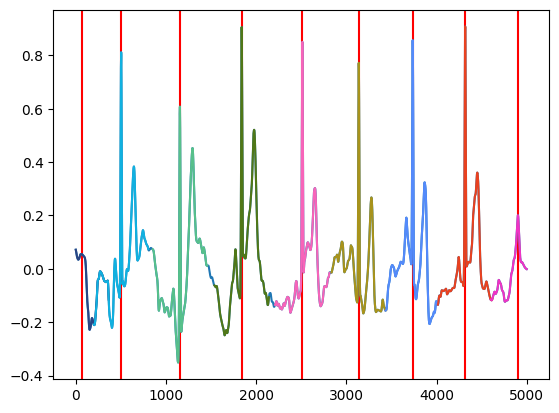

In [110]:
for p in simple_peaks[0]:
    plt.axvline(p, color='red')
plt.plot(cleaned_signal)
plot_col = [tuple(np.random.uniform(0,1, size=3)) for i in range(len(simple_segments))]
for k,ss in enumerate(simple_segments):
    plt.plot(list(range(ss[0], ss[1])), cleaned_signal[ss[0]:ss[1]], color=plot_col[k])

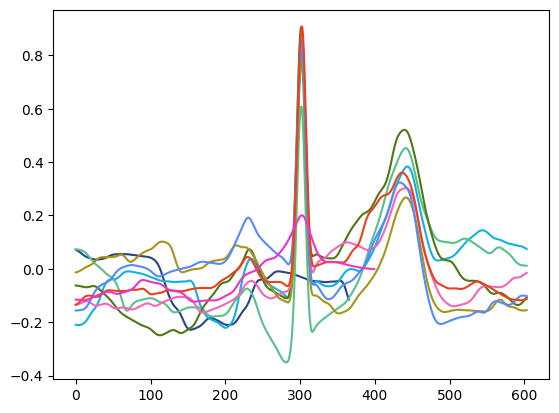

In [111]:
for k,ss in enumerate(simple_segments):
    plt.plot(cleaned_signal[ss[0]:ss[1]], color=plot_col[k])

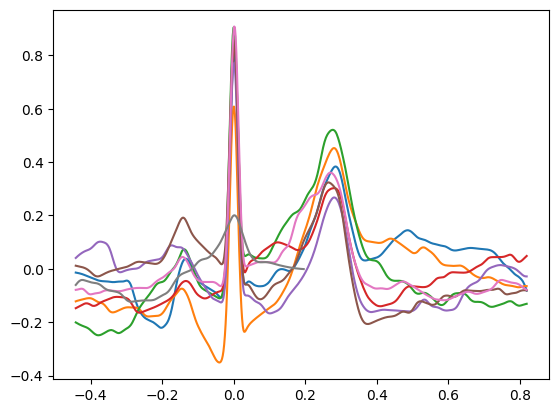

In [60]:
for k,v in ecg_segmentation.items():
    plt.plot(v['Signal'])

In [ ]:
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
from timex.ecg import dataset

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

In [115]:
ecgDS = dataset.ECGDataset(data=os.path.join(BASE_DIR,
                                        DS_DIR,
                                        'records500'),
                       label_binarizer=None,
                       augmentations=[],
                       pretrain= False,
                       encode=False,
                       preprocessing=['savgol', 'bandpass', 'notch'])

First 5 elements of the file_list: ['T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00969_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00106_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00483_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00545_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00133_hr.hea']
No labels available to show unique values


In [116]:
res_dict = defaultdict(dict)
for i in tqdm(range(len(ecgDS))):
    r = ecgDS[i]
    res_dict[r[2]]={
        'signal': r[0],
        'label': r[1],
        'fs': 500
    }
    res_dict[r[2]].update(r[4])

100%|██████████| 21799/21799 [11:49<00:00, 30.74it/s]


In [117]:
from itertools import islice

test_res_dict = dict(islice(res_dict.items(), 10))

In [133]:
ecgExtractor = extractor.ECGxtract(sampling_rate=500, 
                             sanity_check=True,
                             extractor_groups=['wavelets', 'fcc', 'ecgspecific'], 
                             extractor_type='catch22',
                             add_augmented_signal=True)

In [138]:
extractions = ecgExtractor.extract_from_dict(res_dict, SignalCol='signal', FsCol='fs')

100%|██████████| 21799/21799 [37:46<00:00,  9.62it/s] 


In [139]:
len(extractions.keys())

21799

In [140]:
extractions_df = pd.DataFrame(extractions).T

In [141]:
extractions_df.index = [f"records500{''.join(idx.split('records500')[-1])}"
                         for idx in extractions_df.index]

extractions_df.index = [idx.replace('\\', '/').replace('.hea','')
                         for idx in extractions_df.index]

In [142]:
#dx_map = pd.read_csv(os.path.join(BASE_DIR, 'physionet_classification_challenge', 'Dx_map.csv'))
ptbxl_meta = pd.read_csv(os.path.join(BASE_DIR, DS_DIR, 'ptbxl_database.csv'), sep=',')

In [143]:
ptbxl_meta = ptbxl_meta[['filename_hr', 'age', 'sex', 'weight', 'nurse', 
                         'infarction_stadium1', 'infarction_stadium2', 'scp_codes', 'pacemaker']]
ptbxl_meta['filename_hr'] = ptbxl_meta['filename_hr'].str.strip()
ptbxl_meta = ptbxl_meta.set_index('filename_hr')


In [144]:
print(extractions_df.shape)
extractions_df = extractions_df.dropna(how='all')
print(extractions_df.shape)

(21799, 1342)
(21799, 1342)


Text(0.5, 1.0, 'Number of NaN per sample')

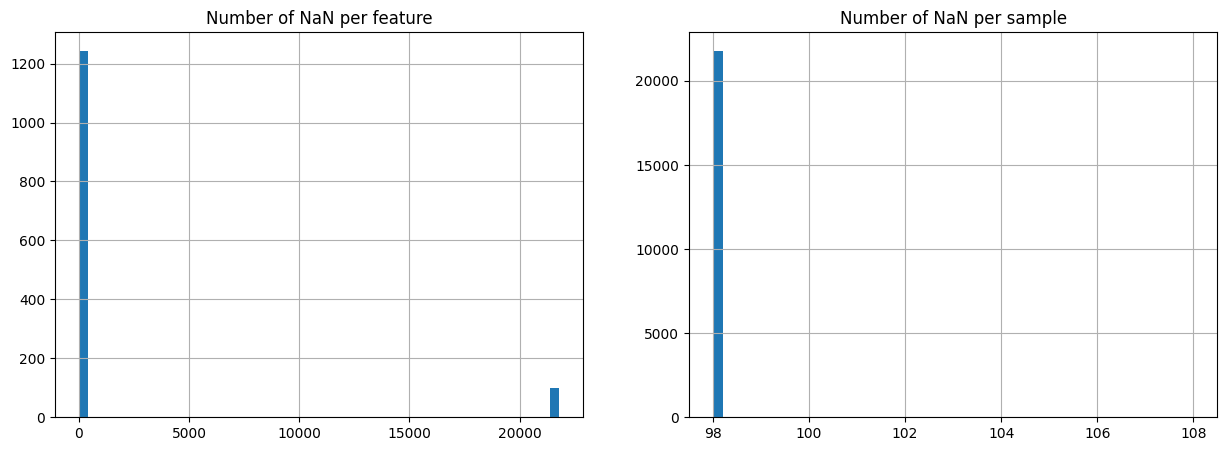

In [145]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
extractions_df.isna().sum(axis=0).hist(bins=50, ax=ax[0])
extractions_df.isna().sum(axis=1).hist(bins=50, ax=ax[1])

ax[0].set_title('Number of NaN per feature')
ax[1].set_title('Number of NaN per sample')

In [146]:
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from umap import UMAP

In [147]:
# add label and demographics
# extractions_df['label'] = None
# for k in _keys:
#     extractions_df.loc[k, 'label'] = res_dict[k]['label']

In [148]:
VAL_COLS = [c for c in extractions_df.columns if c not in ['label', 'segment', 'fs']]

In [149]:
# extractions_df.to_parquet(os.path.join(BASE_DIR, 
#                                        'physionet_classification_challenge', 
#                                        'extractions_wavelets.parquet'))

# extractions_df = pd.read_parquet(os.path.join(BASE_DIR,
#                                                'physionet_classification_challenge', 
#                                                'extractions_wavelets.parquet'))

extractions_df.to_parquet(os.path.join(BASE_DIR, 
                                       DS_DIR, 
                                       'extractions_wavelets.parquet'))

# extractions_df = pd.read_parquet(os.path.join(BASE_DIR,
#                                                'physionet_classification_challenge', 
#                                                'extractions_wavelets.parquet'))

In [161]:
le_pipe_euc = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', IterativeImputer(n_nearest_features=20)),
    ('umap', UMAP(n_neighbors=100, min_dist=0., spread=1, metric='cosine', n_components=3, densmap=False))
], verbose=True)

In [162]:
extractions_2d = le_pipe_euc.fit_transform(extractions_df[VAL_COLS].values)

[Pipeline] ............ (step 1 of 3) Processing scaler, total=   0.8s
[Pipeline] ........... (step 2 of 3) Processing imputer, total= 5.7min
[Pipeline] .............. (step 3 of 3) Processing umap, total=  51.7s


In [163]:
extractions_2d_df = pd.DataFrame(extractions_2d, columns=['d1', 'd2', 'd3'])
extractions_2d_df.index = extractions_df.index
extractions_2d_df = extractions_2d_df.join(ptbxl_meta)
#extractions_2d_df['label'] = extractions_df['label'].values

In [164]:
extractions_2d_df.loc[extractions_2d_df.age>100, 'age'] = extractions_2d_df.loc[extractions_2d_df.age>100, 'age']/10

In [165]:
# collected_labels = [ls.split(",") for ls in extractions_2d_df['label'].unique()]
# label_set = set()
# for ls in collected_labels:
#     for l in ls:
#         label_set.add(l.strip())

# extractions_2d_df[list(label_set)] = False

# extractions_2d_df.loc[:, list(label_set)] = \
#     np.vstack(extractions_2d_df['label'].apply(lambda x: get_label_bool(x)).tolist())

# dx_map[dx_map['Dx'].str.contains('cardia', case=False, na=False)].head(10)
# dx_map['SNOMED CT Code'] = dx_map['SNOMED CT Code'].astype(str)
# dx_map[dx_map['SNOMED CT Code']=='164934002']

In [166]:
def get_label_bool(x):
    bool_list = []
    for label in list(label_set):
        if label in x:
            bool_list.append(True)
        else:
            bool_list.append(False)
    return np.array(bool_list)

In [167]:
dkeys = set()
code_list = []
for ind, str_d in zip(extractions_2d_df.index, extractions_2d_df['scp_codes'].values):
    d = eval(str_d)
    code_list.append({'index': ind, 'CodeDict': d})
    for k in d.keys():
        dkeys.add(k)

new_list = []
for r in code_list:
    r_l = []
    for k in list(dkeys):
        r_l.append(r['CodeDict'].get(k, np.nan))
    new_list.append(r_l)

extractions_2d_df[[f'DIAG_{k}' for k in list(dkeys)]] = new_list

In [168]:
extractions_2d_df[[f'DIAG_{k}' for k in list(dkeys)]].notna().mean().sort_values()

DIAG_PRC(S)    0.000459
DIAG_2AVB      0.000642
DIAG_INJIL     0.000688
DIAG_3AVB      0.000734
DIAG_INJLA     0.000780
                 ...   
DIAG_ASMI      0.108124
DIAG_IMI       0.122758
DIAG_ABQRS     0.152622
DIAG_NORM      0.436442
DIAG_SR        0.768292
Length: 71, dtype: float64

In [169]:
extractions_2d_df

,d1,d2,d3,age,sex,weight,nurse,infarction_stadium1,infarction_stadium2,scp_codes,...,DIAG_1AVB,DIAG_LNGQT,DIAG_TAB_,DIAG_CLBBB,DIAG_IPMI,DIAG_ISCLA,DIAG_ANEUR,DIAG_NT_,DIAG_ISCAL,DIAG_2AVB
records500/00000/00969_hr,-0.343846,2.480485,4.892593,63.0,0,74.0,9.0,NaN,NaN,"{'NORM': 80.0, 'STACH': 0.0}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
records500/00000/00106_hr,9.740632,5.674694,3.087787,38.0,0,75.0,0.0,unknown,NaN,"{'ASMI': 50.0, 'LVH': 15.0, 'ABQRS': 0.0, 'SR'...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
records500/00000/00483_hr,9.581230,3.080130,1.935407,63.0,0,NaN,NaN,unknown,NaN,"{'IMI': 15.0, 'IRBBB': 100.0, 'INJAS': 100.0}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
records500/00000/00545_hr,9.167894,7.626332,2.871892,71.0,0,NaN,NaN,unknown,NaN,"{'IMI': 50.0, 'LVH': 100.0, 'ISC_': 100.0, 'CL...",...,NaN,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN
records500/00000/00133_hr,10.617669,4.342149,1.126448,51.0,0,74.0,2.0,NaN,NaN,"{'NDT': 100.0, 'SR': 0.0}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
records500/21000/21745_hr,11.134381,6.429564,-0.551382,50.0,0,NaN,0.0,NaN,NaN,"{'1AVB': 100.0, 'SR': 0.0}",...,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
records500/21000/21724_hr,11.095654,5.471509,0.974011,68.0,0,NaN,0.0,NaN,NaN,"{'NORM': 100.0, 'IRBBB': 100.0, 'SR': 0.0}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
records500/21000/21810_hr,10.638397,6.990415,2.020565,56.0,1,NaN,1.0,NaN,NaN,"{'NORM': 100.0, 'SR': 0.0}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
records500/21000/21032_hr,-0.534917,2.856486,5.281279,69.0,0,NaN,0.0,unknown,NaN,"{'IMI': 50.0, 'ABQRS': 0.0, 'AFIB': 0.0}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Figure size 1500x1000 with 0 Axes>

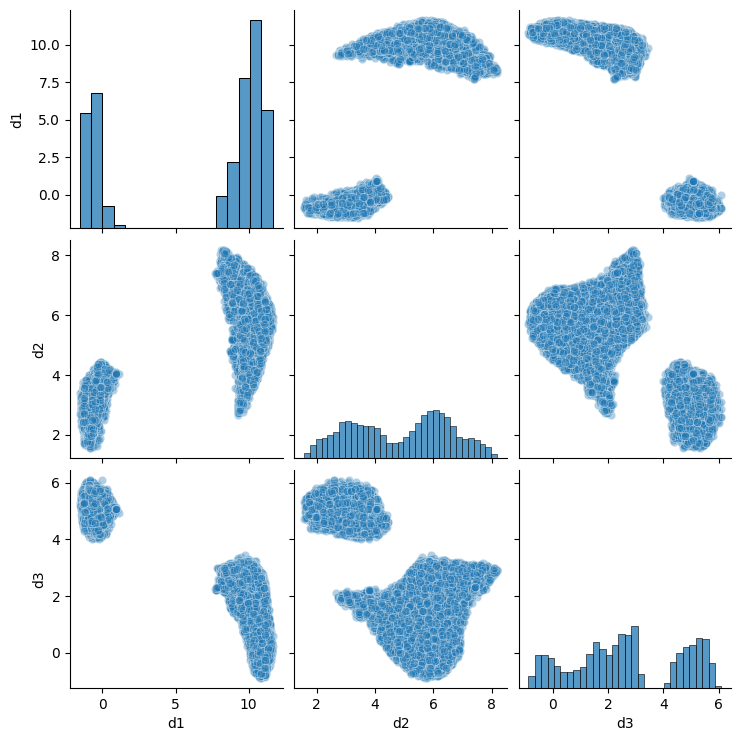

In [173]:
import seaborn as sns
plt.figure(figsize=(15, 10))
sns.pairplot(data=extractions_2d_df, 
             x_vars=['d1', 'd2', 'd3'], 
             y_vars=['d1', 'd2', 'd3'],
             kind='scatter', # scatter
             plot_kws={'alpha': 0.35})

In [ ]:
signals, info = nk.ecg_process(raw_signals[1], sampling_rate=500)
nk.ecg_plot(signals, info)
fig = plt.gcf()
fig.set_size_inches(12, 5, forward=True)